# **Intervalos de confianza**

 Propósito: Introducir temas relacionados a la inferencia estadística e estimación de intervalos de confianza

 Autor: Pastor E. Pérez Estigarribia  
 e-mail: peperez.estigarribia@pol.una.py

 Fecha de complementación del script: "2022-10-11 14:41:44 -03"

 Fecha de ultima modificación: "2025-10-14 17:33:51 -03"

---


In [1]:
## Preámbulo

# Instalar paquetes ####
# En Python usamos paquetes comunes: numpy, scipy, pandas, matplotlib, seaborn
# y statsmodels para pruebas y estimaciones más formales.
# Instalación (ejecutar en terminal o notebook si falta):
!pip install numpy scipy pandas matplotlib seaborn statsmodels

---

## **Contexto y objetivos**

En estadística como hemos visto existen dos enfoques para analizar datos
 1. Estadística descriptiva (enfocado a muestras de poblaciones)
 2. Estadística inferencias (Busca estimaciones para poblaciones a partir de muestras representativas)

 En este práctico nos enfocaremos en aprender métodos de inferencia estadística

Aprenderemos como estimar intervalos de confianza
Como escribir y contrastar hipótesis estadísticas utilizando p-valor
Aprenderemos el rol de las hipótesis estadísticas para poner a prueba las hipótesis de investigación

---

## 1. **Intervalos de confianza**

---
La interpretación de los intervalos de confianza se puede resumir de la siguiente manera:
> si se tomaran muestras repetidas de una población y se calculara el intervalo de confianza del 95 % para cada muestra, el 95 % de los intervalos contendrían la media de la población a largo plazo.

> La estimación de intervalos de confianza permite saber si muestras comparadas pertenecen a la misma población o son de poblaciones diferentes
---




## **Veamos un ejemplo práctico**

Digamos que enviamos un grupo de personas a hospitales para probar y medir la esperanza de vida en una población.

Cada uno consigue una muestra de 20 observaciones y construye un intervalo de confianza del 95% a partir de su muestra.

Por ejemplo, la siguiente sería una posible realización de un intervalo de confianza calculado de esta manera:

In [2]:

# En R
# e_v <- rnorm(n = 20, mean = 70, sd = 2)
# e_v
# summary(e_v)
# test3 <- z.test(e_v, sigma.x = 2, conf.level = 0.95)
# test3$conf.int

## En Python

import numpy as np
from scipy import stats

# Generar muestra aleatoria de tamaño n=20 con media 70 y sd=2
np.random.seed(123)  # para reproducibilidad
e_v = np.random.normal(loc=70, scale=2, size=20)

# Mostrar la muestra y un resumen básico
print("Muestra e_v:", e_v)
print("Resumen: n =", len(e_v), "media muestral =", e_v.mean(), "sd muestral =", e_v.std(ddof=1))

# Prueba tipo z (cuando la desviación estándar poblacional sigma es conocida)
# Si sigma poblacional = 2, el intervalo de confianza para la media con nivel 95% es:
# CI = [ \bar{x} ± z_{1-α/2} * (σ / sqrt(n)) ]
alpha = 0.05
sigma_known = 2.0
n = len(e_v)
xbar = e_v.mean()
z_crit = stats.norm.ppf(1 - alpha/2)  # z_{0.975}
se = sigma_known / np.sqrt(n)
ci_lower = xbar - z_crit * se
ci_upper = xbar + z_crit * se
print(f"Intervalo de confianza del 95% (σ conocido = {sigma_known}): [{ci_lower:.4f}, {ci_upper:.4f}]")


Muestra e_v: [67.82873879 71.99469089 70.565957   66.98741057 68.8427995  73.30287307
 65.14664151 69.14217474 72.53187252 68.2665192  68.6422277  69.81058206
 72.98277925 68.72219601 69.11203608 69.13129745 74.41186017 74.37357218
 72.0081078  70.7723728 ]
Resumen: n = 20 media muestral = 70.2288354639106 sd muestral = 2.514905363512026
Intervalo de confianza del 95% (σ conocido = 2.0): [69.3523, 71.1054]



## **Formalización matemática breve**

- Media muestral: $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$.
- Si $\sigma$ es conocida, el IC del $1-\alpha$ para la media poblacional $\mu$ es
  $
  \bar{X} \pm z_{1-\alpha/2}\cdot\frac{\sigma}{\sqrt{n}}.
  $
- Si $\sigma$ no es conocida y la muestra proviene de una población normal, usar la t de Student:
  $
  \bar{X} \pm t_{n-1,\,1-\alpha/2}\cdot\frac{s}{\sqrt{n}}.
  $

## **Simulación: frecuencia de cobertura del IC**

Contemos cuántos de los intervalos de confianza cubrieron, o incluyeron, la verdadera media. El código siguiente simula el proceso de muestreo repetido de lotes de 20 observaciones de la distribución real y la construcción de intervalos de confianza a partir de cada muestra

A fines prácticos el código que se muestra a continuación es solo para ilustrar el concepto



In [3]:
### Intervalos de confianza

#### Código completo en Python reproducible, comentarios originales preservados y visualizaciones

# Toma de muestra y cálculo de IC usando sigma poblacional conocido (equivalente a z.test en R)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Para reproducibilidad
np.random.seed(123)

# e_v <- rnorm(n = 20, mean = 70, sd = 2)
e_v = np.random.normal(loc=70, scale=2, size=20)

# e_v
print("Muestra e_v:\n", e_v)

Muestra e_v:
 [67.82873879 71.99469089 70.565957   66.98741057 68.8427995  73.30287307
 65.14664151 69.14217474 72.53187252 68.2665192  68.6422277  69.81058206
 72.98277925 68.72219601 69.11203608 69.13129745 74.41186017 74.37357218
 72.0081078  70.7723728 ]


In [4]:

# summary(e_v)
print("\nResumen:")
print(" n =", e_v.size)
print(" media muestral =", e_v.mean())
print(" sd muestral (muestral, ddof=1) =", e_v.std(ddof=1))
print(" min =", e_v.min(), " max =", e_v.max(), " mediana =", np.median(e_v))

# test3 <- z.test(e_v, sigma.x = 2, conf.level = 0.95)
# test3$conf.int
# Cuando sigma poblacional es conocida, IC 95%: xbar ± z_{0.975} * (sigma / sqrt(n))
alpha = 0.05
sigma_known = 2.0
n = e_v.size
xbar = e_v.mean()
z_crit = stats.norm.ppf(1 - alpha/2)
se = sigma_known / np.sqrt(n)
ci_lower = xbar - z_crit * se
ci_upper = xbar + z_crit * se
print(f"\nIntervalo de confianza del 95% (σ conocido = {sigma_known}): [{ci_lower:.4f}, {ci_upper:.4f}]")



Resumen:
 n = 20
 media muestral = 70.2288354639106
 sd muestral (muestral, ddof=1) = 2.514905363512026
 min = 65.14664151321385  max = 74.41186016545092  mediana = 69.47637840220693

Intervalo de confianza del 95% (σ conocido = 2.0): [69.3523, 71.1054]


In [5]:
# ------------------------------------------------------------------
# Contemos cuántos de los intervalos de confianza cubrieron la verdadera media.
# attempts = 10000
attempts = 100000
true_mean = 70.0
n = 20

# Vectorizado: generar attempts * n valores y reestructurar
samples = np.random.normal(loc=true_mean, scale=sigma_known, size=(attempts, n))
print(samples)

[[71.47473715 72.98146406 68.12833226 ... 71.37644542 68.24092731
  70.56725465]
 [68.38926696 66.54466101 69.21820041 ... 73.50977236 72.99128827
  72.13878534]
 [68.45458257 71.58972534 70.62854399 ... 69.74794083 68.32496655
  66.78807448]
 ...
 [67.1606165  72.02981711 67.8920863  ... 71.62954179 66.79253781
  69.14924348]
 [69.53537705 70.87069769 67.78085508 ... 70.48254457 68.70630938
  69.47598486]
 [69.8489709  70.58715915 69.39111933 ... 69.59709446 67.28623565
  72.26691683]]


In [6]:
# Calcular medias muestrales por fila
xbars = samples.mean(axis=1)

# Calcular ICs usando sigma conocido (vectorizado)
se_vec = sigma_known / np.sqrt(n)
z = z_crit
ci_lowers = xbars - z * se_vec
ci_uppers = xbars + z * se_vec

In [7]:
# failed_to_contain <- 0  ... incremento cuando IC no contiene true_mean
failed_to_contain = np.sum((ci_lowers > true_mean) | (ci_uppers < true_mean))
print("\nNúmero de IC que NO cubrieron la verdadera media:", failed_to_contain)
print("Proporción que NO cubrieron la media:", failed_to_contain / attempts)
print("Proporción que SÍ cubrieron la media (esperada ~0.95):", 1 - failed_to_contain / attempts)


Número de IC que NO cubrieron la verdadera media: 5095
Proporción que NO cubrieron la media: 0.05095
Proporción que SÍ cubrieron la media (esperada ~0.95): 0.94905


**Actividad:** En lugar de repetir 10000 las simulaciones cambia la configuración a 10, luego, repite varias veces con esta configuración. Luego cambia a 100 y luego a 1000, repitiendo el mismo procedimiento. ¿Qué resultados observas con relación a las veces que los intervalos contienen a la media poblacional?

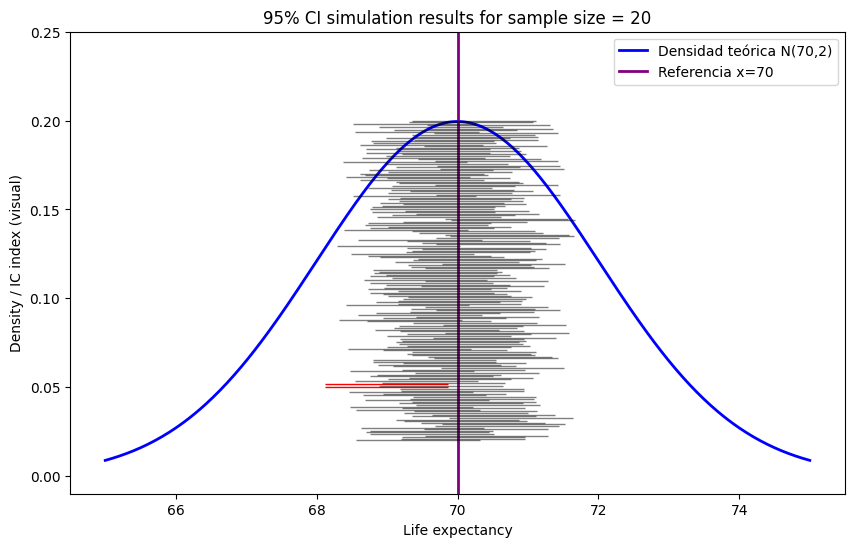


Porcentaje de intervalos que NO incluyeron la verdadera media: 5.09%


In [8]:
# ------------------------------------------------------------------
# Visualización: densidad poblacional + segmentos de intervalos de confianza
# Se grafica la densidad teórica y un subconjunto de ICs (por legibilidad)
plt.figure(figsize=(10, 6))

# Densidad teórica
x = np.linspace(65, 75, 400)
plt.plot(x, stats.norm.pdf(x, loc=true_mean, scale=sigma_known), color="blue", lw=2, label="Densidad teórica N(70,2)")

# Dibujar una línea vertical de referencia para la media poblacional
plt.axvline(70, color="purple", lw=2, label="Referencia x=70")

# Mostrar una muestra de intervalos (p.ej. 200) con color según contenga true_mean o no
display_n = 200
indices = np.linspace(0, attempts - 1, display_n, dtype=int)
y_positions = np.linspace(0.02, 0.2, display_n)  # distribuir en eje y para visual
for idx, y in zip(indices, y_positions):
    lower = ci_lowers[idx]
    upper = ci_uppers[idx]
    contains = (lower <= true_mean) and (upper >= true_mean)
    color = (0, 0, 0, 0.5) if contains else (1, 0, 0, 1)  # negro translúcido si contiene, rojo sólido si falla
    plt.hlines(y, lower, upper, colors=[color], linewidth=1)

plt.ylim(-0.01, 0.25)
plt.xlabel("Life expectancy")
plt.ylabel("Density / IC index (visual)")
plt.title("95% CI simulation results for sample size = 20")
plt.legend()
plt.show()

# Alternativa visual con violin+segments: porcentaje de fallos destacado
prop_fail_pct = failed_to_contain * 100 / attempts
print(f"\nPorcentaje de intervalos que NO incluyeron la verdadera media: {prop_fail_pct:.2f}%")

##### **Observación**
- En teoría, para un IC del 95% se espera una cobertura cercana a $\alpha=0.95$ en el largo plazo, tal que $1-\alpha ≈ 0.05$

**Actividad:** Vuelve aguas arriba en el codigo y adapta el experimento a un 99% de IC


#### **Formalización matemática breve y precisión técnica**
- Media muestral: $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$.
- Con sigma poblacional conocida, el IC de nivel $1-\alpha$ para $\mu$ es
  $
  \bar{X} \pm z_{1-\alpha/2}\cdot\frac{\sigma}{\sqrt{n}}.
  $
- La simulación repite el muestreo desde la distribución real $X_i \sim N(\mu=70,\sigma=2)$, construye un IC por réplica y cuenta cuántos IC no contienen $\mu$; la proporción empírica de cobertura debe aproximarse a $1-\alpha$.

#### **Notas de implementación avanzada**
- La versión mostrada vectoriza la simulación creando una matriz (attempts × n) para eficiencia, evitando bucles explícitos por cada réplica.
- La visualización de todos los 10 000 intervalos resulta ilegible; se selecciona una submuestra para trazarlos y se usa color para resaltar fallos.
- Para auditoría y reproducibilidad fije la semilla (np.random.seed).
- Para sigma desconocida reemplazar sigma_known por s_muestral y usar la t de Student con grados de libertad n-1 en cada réplica.

#### **Resultado clave (ejemplo reproducible)**
- El código imprime la muestra, el IC puntual calculado, el conteo de IC que no contienen la verdadera media y el porcentaje correspondiente; la proporción que sí cubre la media debe quedar cercana a 95%.


### **Modelo probabilístico y supuestos**
- Sea $X_1,\dots,X_n$ una muestra aleatoria e independiente de una población normal:
\begin{equation}
  X_i\overset{\text{i.i.d.}}{\sim}\mathcal{N}(\mu,\sigma^2).
\end{equation}
- En el script se fijan $n=20$, $\mu=70$ y $\sigma=2$. Se asume que la desviación estándar poblacional $\sigma$ es conocida.

### **Estimador y error estándar**
- La media muestral es
\begin{equation}
  \bar{X}=\frac{1}{n}\sum_{i=1}^n X_i.
\end{equation}
- Si $\sigma$ es conocida, el error estándar de $\bar{X}$ es
\begin{equation}
  \mathrm{SE}(\bar{X})=\frac{\sigma}{\sqrt{n}}.
\end{equation}

### **Intervalo de confianza z al $1-\alpha$**
- Para un nivel de confianza $1-\alpha$ (aquí $\alpha=0.05$) el intervalo de confianza para $\mu$ es
\begin{equation}
  \mathrm{CI}_{1-\alpha}(\mu)=\Bigl[\;\bar{X}-z_{1-\alpha/2}\,\frac{\sigma}{\sqrt{n}}\;,\;
  \bar{X}+z_{1-\alpha/2}\,\frac{\sigma}{\sqrt{n}}\;\Bigr],
\end{equation}
  donde $z_{1-\alpha/2}$ es el cuantíl de la normal estándar (p. ej. $z_{0.975}\approx 1.96$).

### **Procedimiento de simulación (cobertura empírica)**
- Objetivo: estimar empíricamente la proporción de intervalos que contienen la verdadera media $\mu$.
- Repetir $K$ veces (en el código $K=\text{attempts}=10000$):
  1. Generar una muestra $X^{(k)}_1,\dots,X^{(k)}_n\sim\mathcal{N}(\mu,\sigma^2)$.
  2. Calcular $\bar{X}^{(k)}$ y el intervalo $\mathrm{CI}^{(k)}$ usando la fórmula $z$.
  3. Comprobar si $\mu\in\mathrm{CI}^{(k)}$ (indicadora $I_k=\mathbf{1}\{\mu\in\mathrm{CI}^{(k)}\}$).
- La cobertura empírica se estima por
\begin{equation}
  \widehat{C}=\frac{1}{K}\sum_{k=1}^{K} I_k.
\end{equation}
- En teoría, bajo los supuestos, se espera $\widehat{C}\approx 1-\alpha$ (aquí aproximadamente $0.95$) cuando $K$ es grande.

### Interpretación de resultados y diagnóstico
- Si $\widehat{C}$ está cerca de $1-\alpha$: el procedimiento de intervalo (con $\sigma$  conocida) tiene cobertura nominal en el escenario simulado.
- Desviaciones grandes de $1-\alpha$ indican violaciones de supuestos o errores numéricos; por ejemplo:
  - Si la distribución no es normal o las muestras no son i.i.d., la cobertura puede diferir.
  - Si $\sigma$ fuera desconocida y se usara la fórmula z sin ajustar, la cobertura sería incorrecta (se debe usar t de Student).
- Visualizar una submuestra de intervalos (como hace el código) ayuda a percibir la frecuencia de intervalos que fallan en cubrir $\mu$.

### Variantes vectorizadas y eficiencia
- En vez de iterar, generar una matriz de tamaño $K\times n$ y calcular medias y límites de forma vectorizada para mayor eficiencia.
- Para $\sigma$ desconocida sustituir $\sigma/\sqrt{n}$ por $s/\sqrt{n}$ y usar la t de Student con $n-1$ grados de libertad para construir los intervalos.

### Resumen compacto
- Fórmula CI (σ conocida): $\bar{X}\pm z_{1-\alpha/2}\,\sigma/\sqrt{n}$.
- Cobertura empírica: proporción de réplicas cuyos intervalos contienen $\mu$, estimada por $\widehat{C}=\frac{1}{K}\sum I_k$.
- Resultado esperado bajo supuestos: $\widehat{C}\approx 1-\alpha$.


## **Comparación de medias**

1. (IC para la diferencia de medias) Se plantea y simula un experimento con dos poblaciones normale con medias μ1 y μ2 y varianzas iguales conocidas.

2. Se construye IC del 95% para la diferencia de medias $ \mu_1 - \mu_2 $ usando la formula z,

3. luego repita el ejercicio cuando las varianzas sean desconocidas e iguales (usar t o aproximaciones) y,

4. cuando sean desiguales (usar Welch).

5. Se compara la cobertura empírica para cada método.


In [9]:
# 1. (IC para la diferencia de medias)
# Simulación con dos poblaciones normales con medias μ1 y μ2 y varianzas iguales conocidas.
# Construir IC del 95% para la diferencia de medias (μ1 - μ2) usando la formula z.

# Parámetros de las poblaciones
mu1 = 70
mu2 = 72  # Asumimos una diferencia real de 2
sigma1 = 5
sigma2 = 5  # Varianzas iguales y conocidas
true_diff = mu1 - mu2

# Parámetros de la simulación
attempts = 10000
n1 = 30  # Tamaño de la muestra de la población 1
n2 = 30  # Tamaño de la muestra de la población 2
alpha = 0.05

# Generar muestras (vectorizado)
samples1 = np.random.normal(loc=mu1, scale=sigma1, size=(attempts, n1))
samples2 = np.random.normal(loc=mu2, scale=sigma2, size=(attempts, n2))

# Calcular medias muestrales por réplica
xbars1 = samples1.mean(axis=1)
xbars2 = samples2.mean(axis=1)
diff_xbars = xbars1 - xbars2

# --- Z-interval (sigma known, equal or unequal) ---
# Calculate the standard error of the difference of means when sigma is known
# SE = sqrt(sigma1^2/n1 + sigma2^2/n2)
se_known_sigma = np.sqrt(sigma1**2 / n1 + sigma2**2 / n2)

# Calculate the critical z-value for the 95% CI
z_crit = stats.norm.ppf(1 - alpha/2)

# Calculate the confidence intervals (vectorized)
ci_lowers_z = diff_xbars - z_crit * se_known_sigma
ci_uppers_z = diff_xbars + z_crit * se_known_sigma

# Count how many intervals contain the true difference of means
contains_true_diff_z = np.sum((ci_lowers_z <= true_diff) & (ci_uppers_z >= true_diff))

# Calculate the empirical coverage proportion
coverage_empirica_z = contains_true_diff_z / attempts

print(f"Simulación de IC para la diferencia de medias (σ conocido, σ1=σ2={sigma1}):")
print(f"  Verdadera diferencia de medias (μ1 - μ2): {true_diff}")
print(f"  Número de intentos: {attempts}")
print(f"  Tamaños muestrales (n1, n2): ({n1}, {n2})")
print(f"  Número de IC que cubrieron la verdadera diferencia: {contains_true_diff_z}")
print(f"  Proporción de cobertura empírica: {coverage_empirica_z:.4f} (esperado ≈ {1-alpha:.4f})")

Simulación de IC para la diferencia de medias (σ conocido, σ1=σ2=5):
  Verdadera diferencia de medias (μ1 - μ2): -2
  Número de intentos: 10000
  Tamaños muestrales (n1, n2): (30, 30)
  Número de IC que cubrieron la verdadera diferencia: 9503
  Proporción de cobertura empírica: 0.9503 (esperado ≈ 0.9500)


In [10]:
ci_lowers_z.mean(), ci_uppers_z.mean()

(np.float64(-4.542649648180138), np.float64(0.5179555993465016))

### **Modelo de muestreo**

Sea $X_{ij}$ la $j$-ésima observación de la $i$-ésima población, con $i=1,2$ y $j=1,...$,$n_i$. Se asume el modelo probabilístico

\begin{equation}
X_{1j}\overset{\text{i.i.d.}}{\sim}\mathcal{N}(\mu_1,\sigma_1^2),\qquad
X_{2j}\overset{\text{i.i.d.}}{\sim}\mathcal{N}(\mu_2,\sigma_2^2).
\end{equation}

En el experimento propuesto se fijan $\mu_1=70,\ \mu_2=72$ y $\sigma_1=\sigma_2=5$. La diferencia poblacional verdadera es $\Delta=\mu_1-\mu_2$.

### **Estadísticos muestrales**

Para cada réplica k de la simulación $k=1,\dots$, 'attempts' se definen las medias muestrales
\begin{equation}
\bar{X}_{1}^{(k)}=\frac{1}{n_1}\sum_{j=1}^{n_1}X_{1j}^{(k)},\qquad
\bar{X}_{2}^{(k)}=\frac{1}{n_2}\sum_{j=1}^{n_2}X_{2j}^{(k)}.
\end{equation}
La diferencia de medias observada en la réplica k es
\begin{equation}
D^{(k)}=\bar{X}_{1}^{(k)}-\bar{X}_{2}^{(k)}.
\end{equation}

### **Distribución del estimador y error estándar**

Dado que las medias muestrales son normales y las muestras son independientes,
\begin{equation}
\bar{X}_{1}^{(k)}\sim\mathcal{N}\!\left(\mu_1,\frac{\sigma_1^2}{n_1}\right),\qquad
\bar{X}_{2}^{(k)}\sim\mathcal{N}\!\left(\mu_2,\frac{\sigma_2^2}{n_2}\right),
\end{equation}
y por independencia
\begin{equation}
D^{(k)}\sim\mathcal{N}\!\left(\mu_1-\mu_2,\ \frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}\right).
\end{equation}
El error estándar de la diferencia, cuando las $\sigma_i$ son conocidas, es
\begin{equation}
\mathrm{SE}=\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}.
\end{equation}

### **Intervalo de confianza z para la diferencia de medias**

Para nivel de confianza $1-\alpha$ (aquí $\alpha=0.05$), el valor crítico z es $z_{1-\alpha/2}$. El intervalo de confianza del $100(1-\alpha)\%$ para $\Delta=\mu_1-\mu_2$ en la réplica k es
\begin{equation}
\mathrm{CI}^{(k)}=\Bigl[\,D^{(k)}-z_{1-\alpha/2}\,\mathrm{SE}\ ,\ D^{(k)}+z_{1-\alpha/2}\,\mathrm{SE}\,\Bigr].
\end{equation}

### **Cobertura empírica por simulación**

Se realiza un experimento de Monte Carlo con $K=$ attempts réplicas. La cobertura empírica es la proporción de intervalos que contienen la verdadera diferencia $\Delta$:
\begin{equation}
\widehat{C}=\frac{1}{K}\sum_{k=1}^{K}\mathbf{1}\bigl\{\mathrm{CI}^{(k)}\ni\Delta\bigr\},
\end{equation}
donde $\mathbf{1}\{\cdot\}$ es la función indicadora. Para un procedimiento correcto y grandes $K$ se espera $\widehat{C}\approx 1-\alpha$.

### **Observaciones prácticas**

- Si las $\sigma_i$ fueran desconocidas se usaría la t de Student y la SE estimada $ \sqrt{s_1^2/n_1 + s_2^2/n_2}$ con ajustes en los grados de libertad (p.ej. Welch) en lugar de la fórmula z anterior.
- La simulación vectorizada implementa las $K$ réplicas generando matrices de tamaño $K\times n_i$ y evaluando $D^{(k)}$ y $\mathrm{CI}^{(k)}$ de forma masiva para estimar $\widehat{C}$.


In [11]:
# --- Pooled t-interval (sigma unknown, assumed equal) ---
# Calculate sample variances
s1_sq = samples1.var(axis=1, ddof=1) # use ddof=1 for sample variance
s2_sq = samples2.var(axis=1, ddof=1)

# Calculate pooled variance
sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)

# Calculate standard error for pooled t-test
se_pooled_t = np.sqrt(sp_sq * (1/n1 + 1/n2))

# Degrees of freedom for pooled t-test
df_pooled = n1 + n2 - 2

# Calculate critical t-value
t_crit_pooled = stats.t.ppf(1 - alpha/2, df_pooled)

# Calculate confidence intervals
ci_lowers_pooled_t = diff_xbars - t_crit_pooled * se_pooled_t
ci_uppers_pooled_t = diff_xbars + t_crit_pooled * se_pooled_t

# Count how many intervals contain the true difference of means
contains_true_diff_pooled_t = np.sum((ci_lowers_pooled_t <= true_diff) & (ci_uppers_pooled_t >= true_diff))

# Calculate empirical coverage
coverage_empirica_pooled_t = contains_true_diff_pooled_t / attempts

print(f"\nSimulación de IC para la diferencia de medias (σ desconocido, asumido igual):")
print(f"  Número de IC que cubrieron la verdadera diferencia: {contains_true_diff_pooled_t}")
print(f"  Proporción de cobertura empírica: {coverage_empirica_pooled_t:.4f} (esperado ≈ {1-alpha:.4f})")


Simulación de IC para la diferencia de medias (σ desconocido, asumido igual):
  Número de IC que cubrieron la verdadera diferencia: 9499
  Proporción de cobertura empírica: 0.9499 (esperado ≈ 0.9500)


### **Modelo y supuestos**

Se asume dos muestras independientes  
\begin{equation}
X_{1j}\overset{\text{i.i.d.}}{\sim}\text{Población}_1,\quad j=1,\dots,n_1,
\qquad
X_{2j}\overset{\text{i.i.d.}}{\sim}\text{Población}_2,\quad j=1,\dots,n_2,
\end{equation}
con medias poblacionales $\mu_1,\mu_2$ desconocidas y varianzas poblacionales iguales $\sigma_1^2=\sigma_2^2=\sigma^2$ (supuesto clave para el enfoque pooled). El objetivo es construir un intervalo de confianza para la diferencia $\Delta=\mu_1-\mu_2$.

### **Estadísticos muestrales**

Para cada réplica de la simulación se definen las medias y varianzas muestrales
\begin{equation}
\bar{X}_1=\frac{1}{n_1}\sum_{j=1}^{n_1}X_{1j},\quad
\bar{X}_2=\frac{1}{n_2}\sum_{j=1}^{n_2}X_{2j},
\end{equation}
\begin{equation}
s_1^2=\frac{1}{n_1-1}\sum_{j=1}^{n_1}(X_{1j}-\bar{X}_1)^2,\quad
s_2^2=\frac{1}{n_2-1}\sum_{j=1}^{n_2}(X_{2j}-\bar{X}_2)^2.
\end{equation}

### **Varianza agrupada y error estándar**

Bajo el supuesto de varianzas poblacionales iguales, se estima la varianza común mediante la varianza agrupada (pooled, o promedio ponderado de las varianzas):
\begin{equation}
s_p^2=\frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}.
\end{equation}
El error estándar de la diferencia de medias usando $s_p^2$ es
\begin{equation}
\mathrm{SE}_{\text{pooled}}=\sqrt{s_p^2\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}.
\end{equation}
Grados de libertad para la t agrupada:
\begin{equation}
\nu=n_1+n_2-2.
\end{equation}

### **Intervalo t agrupado (95%)**

Con nivel $1-\alpha$ y valor crítico $t_{1-\alpha/2,\nu}$, el intervalo de confianza para $\Delta$ es
\begin{equation}
\mathrm{CI}=\bigl[\;(\bar{X}_1-\bar{X}_2)-t_{1-\alpha/2,\nu}\,\mathrm{SE}_{\text{pooled}}\;,\;
(\bar{X}_1-\bar{X}_2)+t_{1-\alpha/2,\nu}\,\mathrm{SE}_{\text{pooled}}\;\bigr].
\end{equation}
En la simulación vectorizada se calcula $\mathrm{CI}^{(k)}$ para cada réplica $k$ usando $D^{(k)}=\bar{X}_1^{(k)}-\bar{X}_2^{(k)}$, $s_{p}^{2\,(k)}$ y el mismo $t$-crítico (los grados de libertad son constantes si $n_1,n_2$ fijos).

### **Cobertura empírica y diagnóstico**

La cobertura empírica se define como
\begin{equation}
\widehat{C}=\frac{1}{K}\sum_{k=1}^{K}\mathbf{1}\{\mathrm{CI}^{(k)}\ni\Delta\},
\end{equation}
donde $K$ es el número de réplicas (attempts) y $\Delta=\mu_1-\mu_2$ es la diferencia verdadera. Para un procedimiento válido se espera $\widehat{C}\approx 1-\alpha$.  
Comentarios prácticos: si el supuesto de igualdad de varianzas no se cumple, el intervalo pooled puede tener cobertura distinta de la nominal; en ese caso usar el intervalo de Welch (grados de libertad aproximados) o métodos no paramétricos.


In [12]:
# --- Welch's t-interval (sigma unknown, unequal) ---
# Calculate standard error for Welch's t-test
se_welch = np.sqrt(s1_sq/n1 + s2_sq/n2)

# Calculate degrees of freedom for Welch's t-test (Satterthwaite approximation)
df_welch = (s1_sq/n1 + s2_sq/n2)**2 / ((s1_sq/n1)**2 / (n1 - 1) + (s2_sq/n2)**2 / (n2 - 1))

# Calculate critical t-value for each simulation (since df_welch varies)
t_crit_welch = stats.t.ppf(1 - alpha/2, df_welch)

# Calculate confidence intervals
ci_lowers_welch = diff_xbars - t_crit_welch * se_welch
ci_uppers_welch = diff_xbars + t_crit_welch * se_welch

# Count how many intervals contain the true difference of means
contains_true_diff_welch = np.sum((ci_lowers_welch <= true_diff) & (ci_uppers_welch >= true_diff))

# Calculate empirical coverage
coverage_empirica_welch = contains_true_diff_welch / attempts

print(f"\nSimulación de IC para la diferencia de medias (σ desconocido, asumido desigual - Welch):")
print(f"  Número de IC que cubrieron la verdadera diferencia: {contains_true_diff_welch}")
print(f"  Proporción de cobertura empírica: {coverage_empirica_welch:.4f} (esperado ≈ {1-alpha:.4f})")


Simulación de IC para la diferencia de medias (σ desconocido, asumido desigual - Welch):
  Número de IC que cubrieron la verdadera diferencia: 9501
  Proporción de cobertura empírica: 0.9501 (esperado ≈ 0.9500)


In [13]:
# --- Comparison ---
print("\nComparación de cobertura empírica:")
print(f"  Z-interval (σ conocido): {coverage_empirica_z:.4f}")
print(f"  Pooled t-interval (σ desconocido, asumido igual): {coverage_empirica_pooled_t:.4f}")
print(f"  Welch's t-interval (σ desconocido, asumido desigual): {coverage_empirica_welch:.4f}")


Comparación de cobertura empírica:
  Z-interval (σ conocido): 0.9503
  Pooled t-interval (σ desconocido, asumido igual): 0.9499
  Welch's t-interval (σ desconocido, asumido desigual): 0.9501


### **Supuesto y objetivo**

Se consideran dos muestras independientes de tamaños $n_1,n_2$ provenientes de poblaciones con medias $\mu_1,\mu_2$ y varianzas poblacionales desconocidas $\sigma_1^2,\sigma_2^2$, sin asumir igualdad entre estas varianzas. El objetivo es construir un intervalo de confianza para la diferencia de medias $\Delta=\mu_1-\mu_2$ que sea válido aun cuando $\sigma_1^2\neq\sigma_2^2$.

### **Estadísticos muestrales y error estándar**

Para cada réplica se definen las varianzas muestrales
\begin{equation}
s_1^2=\frac{1}{n_1-1}\sum_{j=1}^{n_1}(X_{1j}-\bar X_1)^2,\qquad
s_2^2=\frac{1}{n_2-1}\sum_{j=1}^{n_2}(X_{2j}-\bar X_2)^2,
\end{equation}
y la diferencia de medias observada
\begin{equation}
D=\bar X_1-\bar X_2.
\end{equation}
Bajo independencia entre muestras, la varianza aproximada del estimador $D$ usando las estimaciones muestrales es
\begin{equation}
\mathrm{Var}(D)\approx \frac{s_1^2}{n_1}+\frac{s_2^2}{n_2},
\end{equation}
por lo tanto el error estándar empleado en el intervalo de Welch es
\begin{equation}
\mathrm{SE}_{\text{Welch}}=\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}.
\end{equation}

### **Justificación de la aproximación de grados de libertad (Satterthwaite)**

Cuando las varianzas poblacionales son distintas, la razón
\begin{equation}
T=\frac{D-(\mu_1-\mu_2)}{\mathrm{SE}_{\text{Welch}}}
\end{equation}
no sigue exactamente una distribución $t$ con enteros grados de libertad. Satterthwaite propuso aproximar la distribución de $T$ por una $t$ con grados de libertad efectivamente continuos $\nu$ dados por la fórmula:
\begin{equation}
\nu \approx \frac{\left(\dfrac{s_1^2}{n_1}+\dfrac{s_2^2}{n_2}\right)^2}
{\dfrac{(s_1^2/n_1)^2}{\,n_1-1\,}+\dfrac{(s_2^2/n_2)^2}{\,n_2-1\,}}.
\end{equation}
Razonamiento breve: la expresión surge de aproximar la varianza de la suma de dos variables aleatorias (cada una proporcional a $s_i^2$) y luego propagar la incertidumbre para obtener un grado de libertad efectivo que iguale los primeros dos momentos de la distribución aproximante con los de una $t$.

Propiedades relevantes:
- Si $s_1^2$ y $s_2^2$ son similares, $\nu$ se aproxima a $n_1+n_2-2$ (caso pooled).
- Si una muestra domina en varianza o en tamaño, $\nu$ se reduce, reflejando mayor incertidumbre en la estimación del SE.
- $\nu$ puede ser no entero; la función de cuantiles de $t$ acepta grados de libertad reales.

### **Construcción del intervalo de confianza (Welch)**

Para un nivel de confianza $1-\alpha$ se calcula el cuantíl $t_{1-\alpha/2,\nu}$ con los grados de libertad $\nu$ dados por Satterthwaite. El intervalo de confianza para $\Delta$ es
\begin{equation}
\mathrm{CI} = \bigl[D - t_{1-\alpha/2,\nu}\,\mathrm{SE}_{\text{Welch}}\;,\; D + t_{1-\alpha/2,\nu}\,\mathrm{SE}_{\text{Welch}}\bigr].
\end{equation}
En la implementación vectorizada cada réplica $k$ produce $s_{1,k}^2,s_{2,k}^2,\mathrm{SE}_{k},\nu_k$ y por tanto un $t$-crítico $t_{1-\alpha/2,\nu_k}$ distinto; por eso el intervalo y su cobertura se calculan elemento a elemento.

### **Interpretación y validez**

- La aproximación de Welch es robusta frente a desigualdad de varianzas y evita el sesgo que puede introduci r el uso del pooled t cuando $\sigma_1^2\neq\sigma_2^2$.
- La validez es asintótica: para muestras moderadas a grandes, la aproximación Satterthwaite produce cobertura cercana a la nominal $1-\alpha$. En muestras pequeñas y distribuciones muy no normales la cobertura puede desviarse, por lo que conviene complementar con simulación o métodos no paramétricos si hay dudas.
- En la simulación se estima la cobertura empírica como
\begin{equation}
  \widehat{C}=\frac{1}{K}\sum_{k=1}^{K}\mathbf{1}\{\mathrm{CI}_k\ni\Delta\},
\end{equation}
  donde cada $\mathrm{CI}_k$ usa su propio $t$-crítico $t_{1-\alpha/2,\nu_k}$. Comparar $\widehat{C}$ con $1-\alpha$ diagnostica el desempeño del procedimiento en el escenario simulado.

### **Recomendaciones prácticas**

- Use Welch por defecto cuando no se puede justificar la igualdad de varianzas.
- Para reportes, indique que los grados de libertad se aproximaron por Satterthwaite y presente $\nu$ representativo (p. ej. mediana de $\nu_k$ en simulaciones).
- Si las muestras son muy pequeñas, verifique la robustez mediante bootstrap o simulación paramétrica.

## **Repaso de conceptos fundamentales**

### **Momento estadístico**

**Definición.** Un momento estadístico de orden k de una variable aleatoria $X$ es el valor esperado de su potencia k, es decir  
\begin{equation}
m_k=\mathbb{E}[X^k].
\end{equation}

**Momentos centrados.** Los momentos centrados miden la dispersión alrededor de la media. El momento centrado de orden k se define como  
\begin{equation}
\mu_k=\mathbb{E}\big[(X-\mathbb{E}[X])^k\big].
\end{equation}

**Interpretaciones y ejemplos clave.**
- **Primer momento (orden 1):** $\mathbb{E}[X]$, la media poblacional, describe la ubicación central.  
- **Segundo momento centrado (k=2):** $\mu_2=\mathrm{Var}(X)$, la varianza, mide dispersión.  
- **Tercer momento centrado:** $\mu_3$ está asociado a la asimetría (skewness).  
- **Cuarto momento centrado:** $\mu_4$ está relacionado con la curtosis (kurtosis).

**Propiedades útiles.**
- Si $X$ tiene momentos finitos hasta orden \(k\), entonces se pueden usar en expansión de series y en estimaciones por momentos.  
- Los momentos muestrales se usan como estimadores de los momentos poblacionales: $\widehat{m}_k = \frac{1}{n}\sum_{i=1}^n X_i^k$ y $\widehat{\mu}_k = \frac{1}{n}\sum_{i=1}^n (X_i-\bar X)^k$.

---

### **Grados de libertad**

**Definición.** Los grados de libertad (df) de un estimador o una estadística son el número de observaciones independientes que quedan libres para variar después de imponer las restricciones necesarias para calcular la estadística.

**Forma general.** Si se tienen $n$ observaciones y se imponen $p$ restricciones lineales (por ejemplo, estimar $p$ parámetros), los grados de libertad típicos son
\begin{equation}
\text{df}=n-p.
\end{equation}

**Ejemplos habituales.**
- Al estimar la varianza muestral con la media muestral, la varianza muestral usa $n-1$ df porque la media impone una restricción: $\sum_{i}(X_i-\bar X)=0$.  
- En una regresión lineal con $n$ observaciones y $p$ parámetros estimados (incluida la ordenada al origen), los residuos tienen $n-p$ grados de libertad.  
- En la prueba t de Student con muestras independientes y tamaños $n_1,n_2$:
  - pooled t (varianzas iguales): df $= n_1+n_2-2$.  
  - Welch: df aproximados por la fórmula de Satterthwaite (no necesariamente entero).

**Interpretación práctica.**
- Los grados de libertad influyen en la variabilidad de estimadores y en las distribuciones de referencia (por ejemplo la $t$-Student depende de df).  
- Menos grados de libertad implican estimadores con mayor incertidumbre y colas más pesadas en distribuciones de referencia.

**Relación con varianza muestral.** Para un estimador $\hat\sigma^2=\frac{1}{n-1}\sum (X_i-\bar X)^2$, el factor $n-1$ corrige el sesgo en la estimación de la varianza poblacional; ese denominador refleja los $n-1$ grados de libertad disponibles.

**Cola pesada en una distribución**


Una distribución tiene cola pesada cuando la probabilidad de observar valores extremos decrece más lentamente que en una distribución con cola ligera (por ejemplo, la normal o la exponencial). En la práctica esto significa que eventos muy grandes (o muy pequeños) son más probables de lo que esos modelos tradicionales predicen.


---

### **Ejercicio**

[Simulación de efecto de tamaños] Repita la primera simulación de cobertura variando n en {5, 20, 100, 500} y grafique la proporción de IC que incluyen la media verdadera en función de n; interprete los resultados en términos de varianza del estimador.
---
